# 16 - CNN custom con focal loss y AdamW

CNN propia inspirada en el planteamiento descrito en la memoria: profundidad media, bloques convolucionales con `ELU`, `he_normal`, `BatchNormalization`, `Dropout`, `GlobalMaxPooling2D`, pesos de clase, `CategoricalFocalCrossentropy` y `AdamW`. Se diferencia del `15` porque no usa VGG16: intenta mejorar la generalizacion con una arquitectura especifica para este problema.


## Librerias y configuracion


In [1]:
import json
import time
import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

RUN_START = time.perf_counter()

print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))


2026-06-05 08:55:09.377512: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780649709.599001      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780649709.660018      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780649710.171379      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780649710.171423      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780649710.171426      58 computation_placer.cc:177] computation placer alr

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SEED = 42
BATCH_SIZE = 16
EPOCHS = 100
VALIDATION_SIZE = 0.15
IMAGE_SHAPE = (224, 224, 3)

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

np.random.seed(SEED)
tf.random.set_seed(SEED)


## Datos


### Localizacion de inputs


In [3]:
KAGGLE_INPUT_DIR = Path('/kaggle/input')
WORKDIR = Path('/kaggle/working')

if not KAGGLE_INPUT_DIR.exists():
    raise FileNotFoundError('No existe /kaggle/input. Ejecuta este notebook en Kaggle.')

array_matches = sorted(KAGGLE_INPUT_DIR.rglob('X_all.npy'))
working_candidate = WORKDIR / 'xview_arrays' / 'X_all.npy'
if working_candidate.exists():
    array_matches = [working_candidate] + array_matches

if not array_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro X_all.npy. Anade el dataset xview_arrays creado con 00_1. '
        f'Inputs disponibles: {available_inputs}'
    )

ARRAYS_ROOT = array_matches[0].parent

json_matches = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))
if not json_matches:
    available_inputs = [p.name for p in KAGGLE_INPUT_DIR.iterdir() if p.is_dir()]
    raise FileNotFoundError(
        'No se encontro xview_ann_train.json. Anade tambien el dataset original xview_recognition. '
        f'Inputs disponibles: {available_inputs}'
    )

ANN_JSON = json_matches[0]
DATA_ROOT = ANN_JSON.parent
TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'

print('ARRAYS_ROOT:', ARRAYS_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('ANN_JSON:', ANN_JSON)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


ARRAYS_ROOT: /kaggle/input/datasets/eccvdl/xview-arrays/xview_arrays
DATA_ROOT: /kaggle/input/datasets/eccvdl/xview-recognition
ANN_JSON: /kaggle/input/datasets/eccvdl/xview-recognition/xview_ann_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


### Lectura de arrays


In [4]:
DATA_LOAD_START = time.perf_counter()

X_all = np.load(ARRAYS_ROOT / 'X_all.npy')
y_all_idx = np.load(ARRAYS_ROOT / 'y_all_idx.npy')
filenames = np.load(ARRAYS_ROOT / 'filenames.npy')
image_ids = np.load(ARRAYS_ROOT / 'image_ids.npy')
category_names = np.load(ARRAYS_ROOT / 'category_names.npy').astype(str).tolist()
num_classes = len(category_names)

print('X_all:', X_all.shape, X_all.dtype, 'RAM aprox:', X_all.nbytes / 1024**3, 'GB')
print('y_all_idx:', y_all_idx.shape, y_all_idx.dtype)
print('filenames:', filenames.shape)
print('image_ids:', image_ids.shape)
print('num_classes:', num_classes)
print(category_names)


X_all: (18746, 224, 224, 3) uint8 RAM aprox: 2.6280040740966797 GB
y_all_idx: (18746,) int32
filenames: (18746,)
image_ids: (18746,)
num_classes: 13
['Cargo plane', 'Small car', 'Bus', 'Truck', 'Motorboat', 'Fishing vessel', 'Dump truck', 'Excavator', 'Building', 'Helipad', 'Storage tank', 'Shipping container', 'Pylon']


### Comprobacion de una imagen


Filename: xview_train/Building/0234476c-a017-4c9b-bd2f-872193076cca.tif
Image id: 0234476c-a017-4c9b-bd2f-872193076cca.tif
Shape: (224, 224, 3)
Dtype: uint8
Min / Max: 0 86
Etiqueta: Building
Primeros pixeles del array original:
[[[45 30 19]
  [45 30 19]
  [46 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]

 [[45 30 19]
  [45 30 19]
  [45 30 19]]]
Primeros pixeles normalizados:
[[[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.18039216 0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]

 [[0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]
  [0.1764706  0.11764706 0.07450981]]]


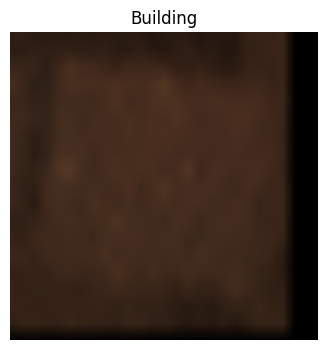

In [5]:
sample_idx = 0
sample_img = X_all[sample_idx]
sample_label_idx = int(y_all_idx[sample_idx])

print('Filename:', filenames[sample_idx])
print('Image id:', image_ids[sample_idx])
print('Shape:', sample_img.shape)
print('Dtype:', sample_img.dtype)
print('Min / Max:', sample_img.min(), sample_img.max())
print('Etiqueta:', category_names[sample_label_idx])
print('Primeros pixeles del array original:')
print(sample_img[:3, :3, :])
print('Primeros pixeles normalizados:')
print((sample_img.astype(np.float32) / 255.0)[:3, :3, :])

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(category_names[sample_label_idx])
plt.axis('off')
plt.show()


### Split train/valid


In [6]:
indices = np.arange(len(X_all))
train_idx, val_idx = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=y_all_idx,
)

X_train = X_all[train_idx]
X_valid = X_all[val_idx]
y_train_idx = y_all_idx[train_idx]
y_valid_idx = y_all_idx[val_idx]

y_train = tf.keras.utils.to_categorical(y_train_idx, num_classes=num_classes).astype(np.float32)
y_valid = tf.keras.utils.to_categorical(y_valid_idx, num_classes=num_classes).astype(np.float32)

DATA_LOAD_TIME = time.perf_counter() - DATA_LOAD_START

print('X_train:', X_train.shape, X_train.dtype, 'RAM aprox:', X_train.nbytes / 1024**3, 'GB')
print('X_valid:', X_valid.shape, X_valid.dtype, 'RAM aprox:', X_valid.nbytes / 1024**3, 'GB')
print('y_train:', y_train.shape, y_train.dtype)
print('y_valid:', y_valid.shape, y_valid.dtype)
print(f'Tiempo carga arrays/split: {DATA_LOAD_TIME:.2f} s')


X_train: (15934, 224, 224, 3) uint8 RAM aprox: 2.2337894439697266 GB
X_valid: (2812, 224, 224, 3) uint8 RAM aprox: 0.3942146301269531 GB
y_train: (15934, 13) float32
y_valid: (2812, 13) float32
Tiempo carga arrays/split: 15.39 s


### Pesos de clase


In [7]:
class_counts = np.bincount(y_train_idx, minlength=num_classes)
class_weight_values = len(y_train_idx) / (num_classes * np.maximum(class_counts, 1))
class_weight_dict = {idx: float(weight) for idx, weight in enumerate(class_weight_values)}
sample_weight_train = np.array([class_weight_dict[int(label)] for label in y_train_idx], dtype=np.float32)

for idx, name in enumerate(category_names):
    print(f'{idx:02d} {name:20s} count={class_counts[idx]:5d} weight={class_weight_dict[idx]:.3f}')


00 Cargo plane          count=  540 weight=2.270
01 Small car            count= 2825 weight=0.434
02 Bus                  count= 1503 weight=0.815
03 Truck                count= 1878 weight=0.653
04 Motorboat            count=  909 weight=1.348
05 Fishing vessel       count=  600 weight=2.043
06 Dump truck           count= 1051 weight=1.166
07 Excavator            count=  671 weight=1.827
08 Building             count= 3055 weight=0.401
09 Helipad              count=   94 weight=13.039
10 Storage tank         count= 1249 weight=0.981
11 Shipping container   count= 1294 weight=0.947
12 Pylon                count=  265 weight=4.625


## Red


### Augmentation


In [8]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomTranslation(height_factor=0.15, width_factor=0.15, fill_mode='reflect'),
    tf.keras.layers.RandomRotation(0.10, fill_mode='reflect'),
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomZoom(height_factor=0.05, width_factor=0.05, fill_mode='reflect'),
    tf.keras.layers.RandomContrast(0.08),
], name='data_augmentation')


I0000 00:00:1780649760.355475      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780649760.361380      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### CNN custom


In [9]:
def conv_block(x, filters, dropout_rate, name):
    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same',
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED),
        name=f'{name}_conv1',
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = tf.keras.layers.ELU(name=f'{name}_elu1')(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding='same',
        use_bias=False,
        kernel_initializer=tf.keras.initializers.HeNormal(seed=SEED + 1),
        name=f'{name}_conv2',
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f'{name}_bn2')(x)
    x = tf.keras.layers.ELU(name=f'{name}_elu2')(x)

    x = tf.keras.layers.MaxPooling2D(pool_size=2, name=f'{name}_pool')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name=f'{name}_dropout')(x)
    return x


inputs = tf.keras.Input(shape=IMAGE_SHAPE)
x = tf.keras.layers.Rescaling(1.0 / 255.0, name='rescaling')(inputs)
x = data_aug(x)
x = tf.keras.layers.BatchNormalization(name='input_bn')(x)

x = conv_block(x, 32, 0.15, 'block1')
x = conv_block(x, 64, 0.20, 'block2')
x = conv_block(x, 128, 0.30, 'block3')
x = conv_block(x, 256, 0.40, 'block4')
x = conv_block(x, 384, 0.45, 'block5')

x = tf.keras.layers.GlobalMaxPooling2D(name='global_max_pool')(x)
x = tf.keras.layers.Dropout(0.50, name='final_dropout')(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='predictions')(x)

model = tf.keras.Model(inputs, outputs, name='cnn_custom_focal_adamw')


### Loss y compilacion


In [10]:
try:
    loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=FOCAL_GAMMA,
        alpha=FOCAL_ALPHA,
    )
    print('Usando tf.keras.losses.CategoricalFocalCrossentropy')
except AttributeError:
    print('CategoricalFocalCrossentropy no disponible; usando implementacion propia')

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_factor = FOCAL_ALPHA * tf.pow(1.0 - y_pred, FOCAL_GAMMA)
        loss = focal_factor * cross_entropy
        return tf.reduce_sum(loss, axis=-1)


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
    loss=loss_fn,
    metrics=['accuracy'],
)

model.summary()


Usando tf.keras.losses.CategoricalFocalCrossentropy


Model: "cnn_custom_focal_adamw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_bn (BatchNormalization)   │ (None, 224, 224, 3)    │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_elu1 (ELU)               │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_elu2 (ELU)               │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_elu1 (ELU)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_elu2 (ELU)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_elu1 (ELU)               │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           51

 Total params: 3,395,065 (12.95 MB)

 Trainable params: 3,391,603 (12.94 MB)

 Non-trainable params: 3,462 (13.52 KB)

### Callbacks


In [13]:
MODEL_PATH = WORKDIR / '16_cnn_custom_focal_adamw.weights.h5'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.75,
        patience=4,
        min_lr=1e-5,
        verbose=1,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print('Modelo guardado en:', MODEL_PATH)


Modelo guardado en: /kaggle/working/16_cnn_custom_focal_adamw.weights.h5


### Entrenamiento


In [14]:
TRAIN_START = time.perf_counter()

history = model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

TRAIN_TIME = time.perf_counter() - TRAIN_START

best_idx = int(np.argmax(history.history['val_accuracy']))
best_value = float(np.max(history.history['val_accuracy']))
print('Best validation model: epoch', best_idx + 1, '- val_accuracy', best_value)
print(f'Tiempo entrenamiento: {TRAIN_TIME:.2f} s')


Epoch 1/100
996/996 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.1595 - loss: 0.6321
Epoch 1: val_accuracy improved from None to 0.11878, saving model to /kaggle/working/16_cnn_custom_focal_adamw.weights.h5

Epoch 1: finished saving model to /kaggle/working/16_cnn_custom_focal_adamw.weights.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 193s 194ms/step - accuracy: 0.1567 - loss: 0.6413 - val_accuracy: 0.1188 - val_loss: 0.6170 - learning_rate: 0.0010
Epoch 2/100
996/996 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.1480 - loss: 0.5837
Epoch 2: val_accuracy improved from 0.11878 to 0.16821, saving model to /kaggle/working/16_cnn_custom_focal_adamw.weights.h5

Epoch 2: finished saving model to /kaggle/working/16_cnn_custom_focal_adamw.weights.h5
996/996 ━━━━━━━━━━━━━━━━━━━━ 191s 192ms/step - accuracy: 0.1657 - loss: 0.5225 - val_accuracy: 0.1682 - val_loss: 0.4933 - learning_rate: 0.0010
Epoch 3/100
996/996 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.1945 - loss: 0.4423
Epoch 3: val_accurac

## Resultados


### Graficas


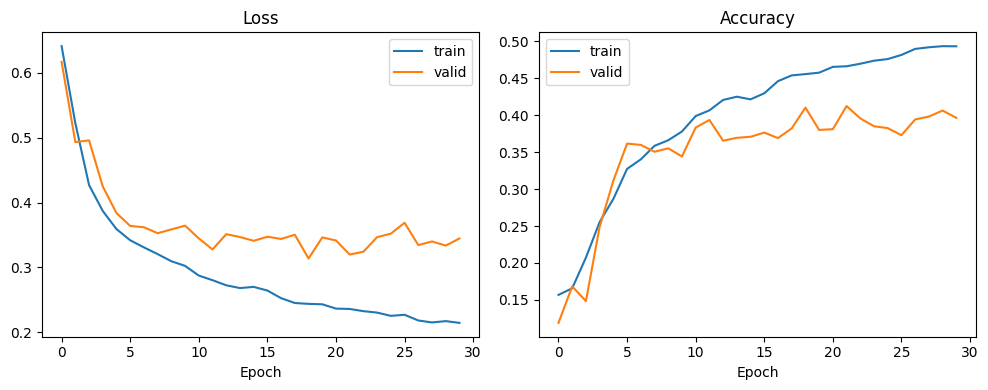

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


### Predicciones de validacion


In [16]:
model.load_weights(MODEL_PATH)

valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, batch_size=BATCH_SIZE, verbose=1)
print('Validation loss:', valid_loss)
print('Validation accuracy:', valid_accuracy)

probs = model.predict(X_valid, batch_size=BATCH_SIZE, verbose=1)
y_pred_idx = np.argmax(probs, axis=1)
y_true_idx = y_valid_idx


176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.4125 - loss: 0.3199
Validation loss: 0.31989535689353943
Validation accuracy: 0.412517786026001
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step


### Matriz de confusion


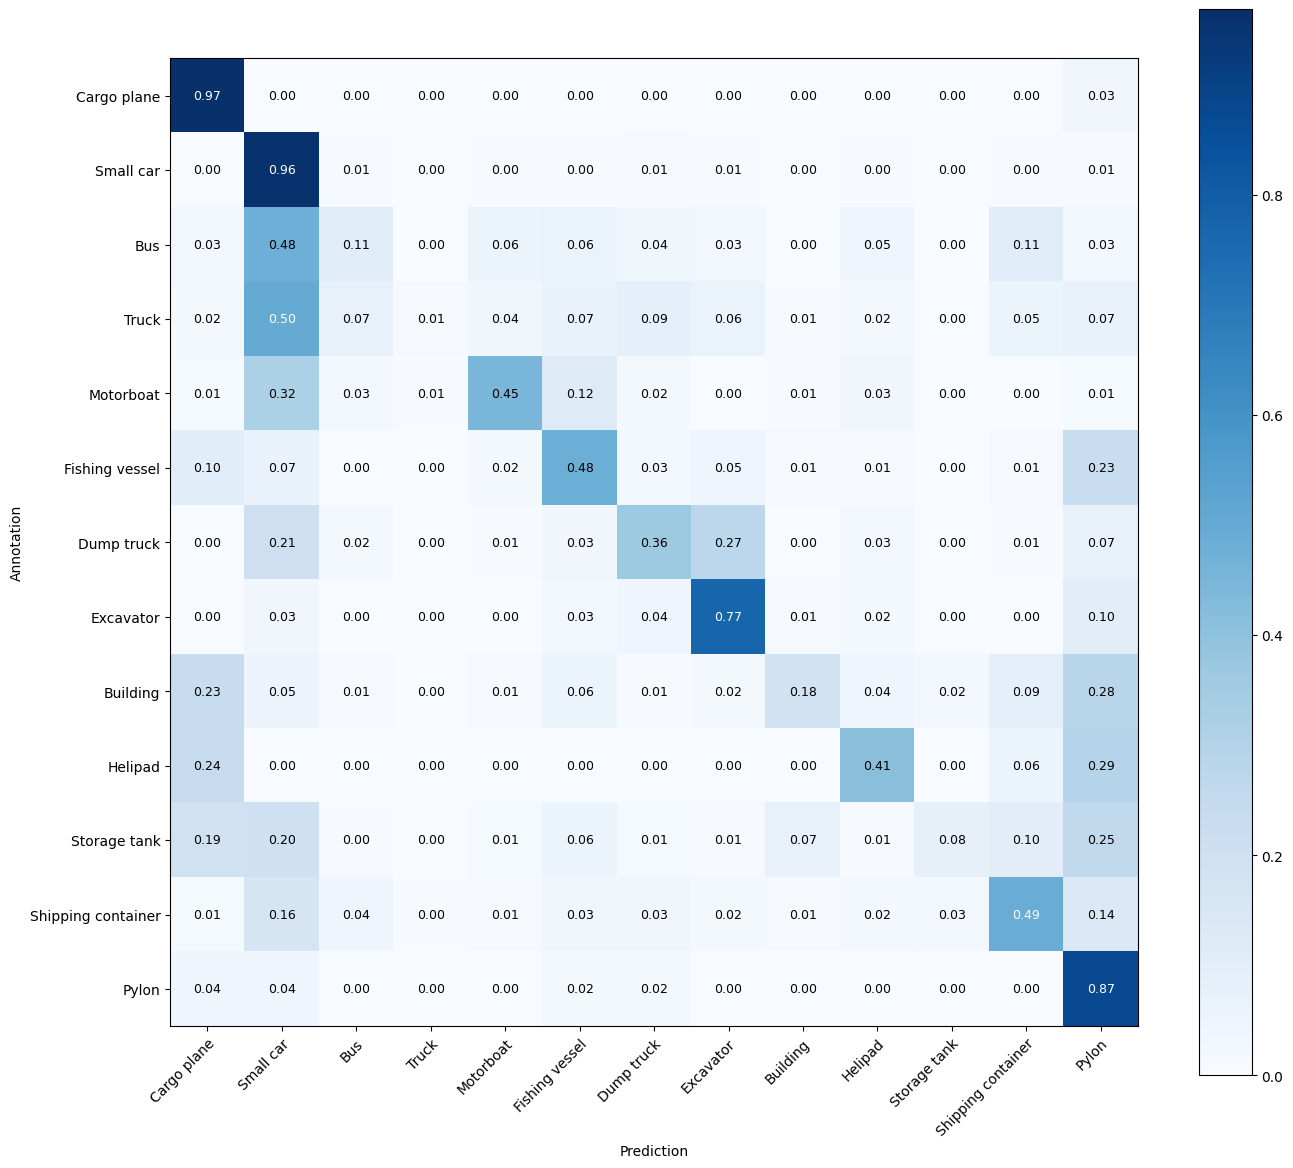

In [17]:
cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(num_classes)))

def draw_confusion_matrix_percent(cm, labels):
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), np.finfo(np.float64).eps)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.colormaps['Blues'], vmin=0.0, vmax=max(0.01, cm_norm.max()))
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel='Annotation',
        xlabel='Prediction',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    threshold = cm_norm.max() / 2.0
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            ax.text(
                j,
                i,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if value > threshold else 'black',
                fontsize=9,
            )

    fig.tight_layout()
    plt.show()
    return cm_norm

cm_norm = draw_confusion_matrix_percent(cm, category_names)


### Metricas


In [18]:
print(classification_report(y_true_idx, y_pred_idx, target_names=category_names, digits=4))


                    precision    recall  f1-score   support

       Cargo plane     0.3129    0.9684    0.4730        95
         Small car     0.4858    0.9579    0.6446       499
               Bus     0.3750    0.1132    0.1739       265
             Truck     0.6000    0.0090    0.0178       332
         Motorboat     0.6261    0.4500    0.5236       160
    Fishing vessel     0.2948    0.4811    0.3656       106
        Dump truck     0.4963    0.3622    0.4188       185
         Excavator     0.4691    0.7712    0.5833       118
          Building     0.8182    0.1837    0.3000       539
           Helipad     0.1014    0.4118    0.1628        17
      Storage tank     0.4474    0.0773    0.1318       220
Shipping container     0.4807    0.4891    0.4848       229
             Pylon     0.1105    0.8723    0.1962        47

          accuracy                         0.4125      2812
         macro avg     0.4322    0.4729    0.3443      2812
      weighted avg     0.5355    0.412

## Codabench


### TTA


In [19]:
def tta_batches(images):
    return [
        np.ascontiguousarray(images),
        np.ascontiguousarray(np.flip(images, axis=2)),
        np.ascontiguousarray(np.flip(images, axis=1)),
        np.ascontiguousarray(np.rot90(images, k=1, axes=(1, 2))),
        np.ascontiguousarray(np.rot90(images, k=2, axes=(1, 2))),
        np.ascontiguousarray(np.rot90(images, k=3, axes=(1, 2))),
    ]


def predict_with_tta(model, images, batch_size=64):
    probs_sum = None
    variants = tta_batches(images)

    for variant in variants:
        probs = model.predict(variant, batch_size=batch_size, verbose=0)
        probs_sum = probs if probs_sum is None else probs_sum + probs

    return probs_sum / len(variants)


### Generacion del submission


In [20]:
CODABENCH_START = time.perf_counter()

def load_test_image(filename):
    return np.array(Image.open(DATA_ROOT / filename).convert('RGB'))

test_files = sorted(TEST_DIR.rglob('*.tif'))
print('Number of testing images:', len(test_files))
assert len(test_files) > 0, 'No se encontraron imagenes .tif en TEST_DIR.'

model.load_weights(MODEL_PATH)
predictions_data = {'images': {}, 'annotations': {}}
batch_size = 64

for start in range(0, len(test_files), batch_size):
    batch_paths = test_files[start:start + batch_size]
    json_filenames = [path.relative_to(TEST_DIR).as_posix() for path in batch_paths]
    load_filenames = [path.relative_to(DATA_ROOT).as_posix() for path in batch_paths]

    images = np.stack([load_test_image(filename) for filename in load_filenames]).astype(np.uint8)
    probs = predict_with_tta(model, images, batch_size=batch_size)
    pred_idx = np.argmax(probs, axis=1)
    pred_scores = np.max(probs, axis=1)

    for offset, (path, json_filename, cls_idx, score) in enumerate(zip(batch_paths, json_filenames, pred_idx, pred_scores)):
        idx = start + offset
        predictions_data['images'][idx] = {
            'image_id': path.name,
            'filename': json_filename,
            'width': 224,
            'height': 224,
        }
        predictions_data['annotations'][idx] = {
            'image_id': path.name,
            'category_id': category_names[int(cls_idx)],
            'score': float(score),
            'bbox': [0, 0, 224, 224],
        }

    print(f'Procesadas {min(start + batch_size, len(test_files))}/{len(test_files)}')

assert len(predictions_data['images']) == len(test_files)
assert len(predictions_data['annotations']) == len(test_files)

prediction_path = WORKDIR / 'prediction_16.json'
submission_path = WORKDIR / 'submission_16.zip'

with open(prediction_path, 'w', encoding='utf-8') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

CODABENCH_TIME = time.perf_counter() - CODABENCH_START

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
print(f'Tiempo Codabench: {CODABENCH_TIME:.2f} s')

from IPython.display import FileLink, display
display(FileLink(str(submission_path)))


Number of testing images: 2365
Procesadas 64/2365
Procesadas 128/2365
Procesadas 192/2365
Procesadas 256/2365
Procesadas 320/2365
Procesadas 384/2365
Procesadas 448/2365
Procesadas 512/2365
Procesadas 576/2365
Procesadas 640/2365
Procesadas 704/2365
Procesadas 768/2365
Procesadas 832/2365
Procesadas 896/2365
Procesadas 960/2365
Procesadas 1024/2365
Procesadas 1088/2365
Procesadas 1152/2365
Procesadas 1216/2365
Procesadas 1280/2365
Procesadas 1344/2365
Procesadas 1408/2365
Procesadas 1472/2365
Procesadas 1536/2365
Procesadas 1600/2365
Procesadas 1664/2365
Procesadas 1728/2365
Procesadas 1792/2365
Procesadas 1856/2365
Procesadas 1920/2365
Procesadas 1984/2365
Procesadas 2048/2365
Procesadas 2112/2365
Procesadas 2176/2365
Procesadas 2240/2365
Procesadas 2304/2365
Procesadas 2365/2365
Archivos generados:
/kaggle/working/prediction_16.json - 731479 bytes
/kaggle/working/submission_16.zip - 165436 bytes
Tiempo Codabench: 82.62 s


/kaggle/working/submission_16.zip

### Resumen de tiempos


In [21]:
TOTAL_TIME = time.perf_counter() - RUN_START
print('Resumen de tiempos')
if 'DATA_LOAD_TIME' in globals():
    print(f'- Carga/preparacion de datos: {DATA_LOAD_TIME:.2f} s')
if 'TRAIN_TIME' in globals():
    print(f'- Entrenamiento: {TRAIN_TIME:.2f} s')
if 'CODABENCH_TIME' in globals():
    print(f'- Codabench con TTA: {CODABENCH_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME:.2f} s')
print(f'- Tiempo total Run All: {TOTAL_TIME / 60:.2f} min')


Resumen de tiempos
- Carga/preparacion de datos: 15.39 s
- Entrenamiento: 5735.59 s
- Codabench con TTA: 82.62 s
- Tiempo total Run All: 6465.35 s
- Tiempo total Run All: 107.76 min
